In [14]:
from pynhd import NLDI
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [19]:
#load combined dataframe
Hydro_DF = pd.read_csv(f'files/Hydro_Df/Hydro_Df', index_col=0, parse_dates=True)

Hydro_DF.head()

,site_no,flow_cms,565_SWE_cm,688_SWE_cm,Unnamed: 0,station_id,Average_Elevation_m,Minimum_Elevation_m,Maximum_Elevation_m,Average_Slope,...,"Developed,_Low_Intensity","Developed,_Medium_Intensity","Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Shrub_Scrub,Grassland_Herbaceous,Woody_Wetlands,Emergent_Herbaceous_Wetlands
1980-10-01,9010500,0.453069,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372
1980-10-02,9010500,0.396435,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372
1980-10-03,9010500,0.368118,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372
1980-10-04,9010500,0.368118,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372
1980-10-05,9010500,0.368118,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372


# SWE Analysis

In [ ]:
df = Hydro_DF

In [22]:
import os
if not os.path.exists('figures'):
    os.makedirs('figures')


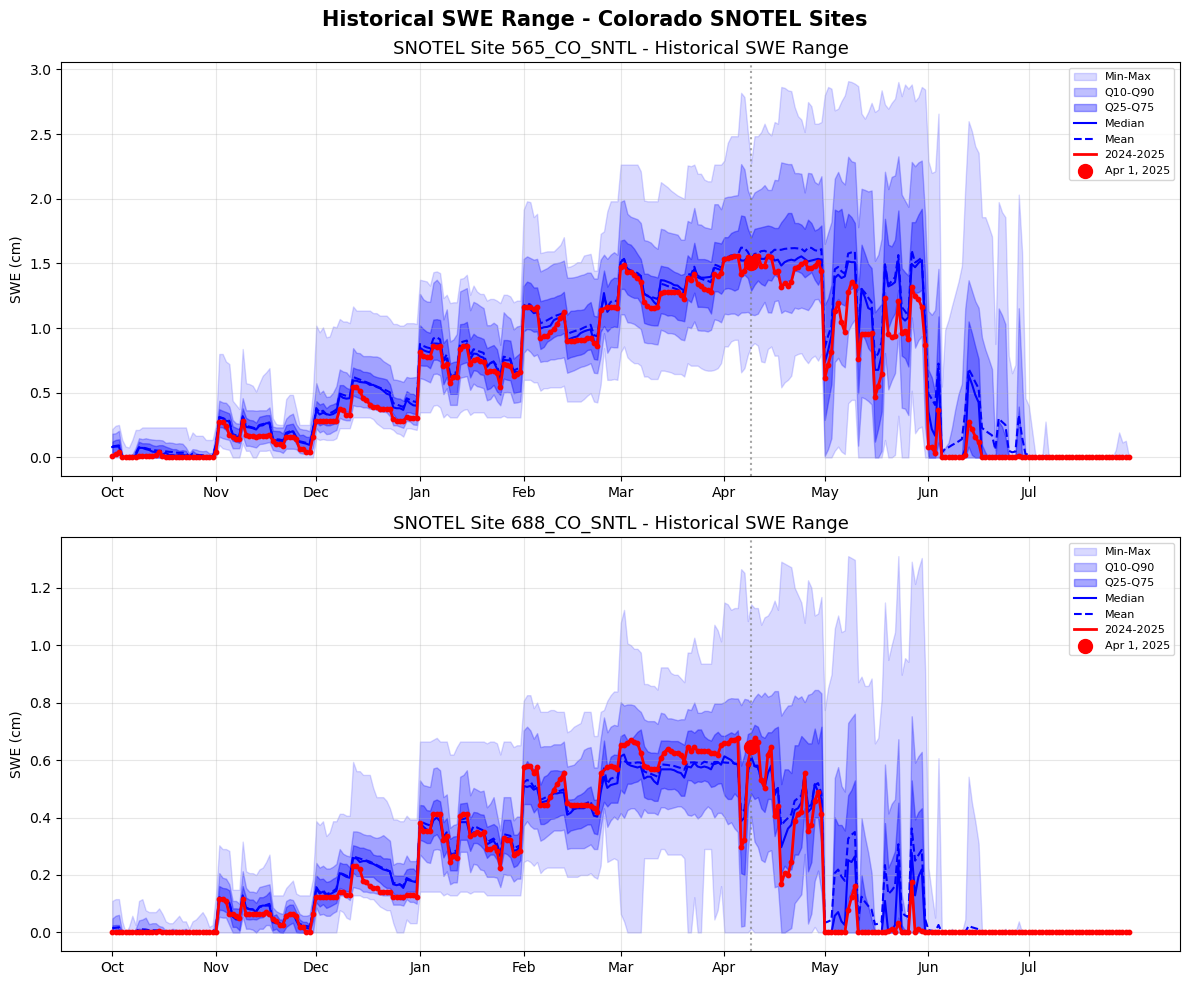

In [37]:

import matplotlib.dates as mdates

def plot_snotel_style(df, swe_col, site_name, ax):
    """Plot historical range of SWE for a single site"""
    
    # Add month and day columns for grouping
    df = df.copy()
    df['M'] = df.index.month
    df['D'] = df.index.day
    df['M-D'] = df.index.strftime('%m-%d')
    
    # Filter to water year (Oct - Jul, removing Aug/Sep)
    df = df[~df['M'].isin([8, 9])]
    
    # Calculate historical stats by day of year
    stats = df.groupby('M-D')[swe_col].agg([
        ('min', 'min'),
        ('Q10', lambda x: x.quantile(0.10)),
        ('Q25', lambda x: x.quantile(0.25)),
        ('median', 'median'),
        ('mean', 'mean'),
        ('Q75', lambda x: x.quantile(0.75)),
        ('Q90', lambda x: x.quantile(0.90)),
        ('max', 'max')
    ]).reset_index()
    
    # Sort by water year order (Oct first)
    stats['sort_key'] = stats['M-D'].apply(lambda x: int(x.split('-')[0]))
    stats['sort_key'] = stats['sort_key'].apply(lambda x: x - 12 if x >= 10 else x + 12)
    stats = stats.sort_values('sort_key').reset_index(drop=True)
    
    x = range(len(stats))
    
    # Plot shaded ranges
    ax.fill_between(x, stats['min'], stats['max'], alpha=0.15, color='blue', label='Min-Max')
    ax.fill_between(x, stats['Q10'], stats['Q90'], alpha=0.25, color='blue', label='Q10-Q90')
    ax.fill_between(x, stats['Q25'], stats['Q75'], alpha=0.35, color='blue', label='Q25-Q75')
    ax.plot(x, stats['median'], color='blue', linewidth=1.5, label='Median')
    ax.plot(x, stats['mean'], color='blue', linewidth=1.5, linestyle='--', label='Mean')
    
    # Plot 2025 water year
    wy2025 = df[(df.index >= '2024-10-01') & (df.index <= '2025-07-31')]
    wy2025 = wy2025[~wy2025.index.month.isin([8, 9])].copy()
    wy2025['M-D'] = wy2025.index.strftime('%m-%d')

    # Map each M-D value to its x position in the stats dataframe
    md_to_x = {md: i for i, md in enumerate(stats['M-D'])}
    wy2025['x_pos'] = wy2025['M-D'].map(md_to_x)

    # Drop rows where M-D doesn't exist in stats
    wy2025 = wy2025.dropna(subset=['x_pos'])
    wy2025 = wy2025.sort_values('x_pos')

    ax.plot(wy2025['x_pos'], wy2025[swe_col], color='red', linewidth=2, label='2024-2025')
    ax.scatter(wy2025['x_pos'], wy2025[swe_col], color='red', s=10, zorder=4)

    # Mark April 1st
    apr1 = wy2025[wy2025['M-D'] == '04-01']
    if not apr1.empty:
        ax.scatter(apr1['x_pos'].values[0], apr1[swe_col].values[0], 
               color='red', zorder=5, s=100, label='Apr 1, 2025')
        ax.axvline(x=apr1['x_pos'].values[0], color='gray', linestyle=':', alpha=0.7)
    
    # X axis labels - show monthly ticks
    month_positions = stats.groupby(stats['M-D'].str[:2]).first().index
    tick_positions = [stats[stats['M-D'].str.startswith(m)].index[0] for m in ['10', '11', '12', '01', '02', '03', '04', '05', '06', '07']]
    tick_labels = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul']
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    
    ax.set_title(f'SNOTEL Site {site_name} - Historical SWE Range', fontsize=13)
    ax.set_ylabel('SWE (cm)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)


# Create figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

plot_snotel_style(df, '565_SWE_cm', '565_CO_SNTL', axes[0])
plot_snotel_style(df, '688_SWE_cm', '688_CO_SNTL', axes[1])

fig.suptitle('Historical SWE Range - Colorado SNOTEL Sites', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/SNOTEL_historical_range.png', dpi=150, bbox_inches='tight')
plt.show()



In [38]:
for swe_col in ['565_SWE_cm', '688_SWE_cm']:
    # Get April 1st 2025 value
    apr1_val = df.loc['2025-04-01', swe_col]
    
    # Get historical stats for April 1st
    hist = df[df.index.strftime('%m-%d') == '04-01'][swe_col]
    hist_mean = hist.mean()
    hist_median = hist.median()
    
    print(f"\nSite: {swe_col}")
    print(f"Apr 1, 2025 SWE: {apr1_val:.2f} cm")
    print(f"Historical Mean: {hist_mean:.2f} cm")
    print(f"Historical Median: {hist_median:.2f} cm")
    print(f"% of Mean: {(apr1_val/hist_mean)*100:.1f}%")
    print(f"% of Median: {(apr1_val/hist_median)*100:.1f}%")


Site: 565_SWE_cm
Apr 1, 2025 SWE: 1.50 cm
Historical Mean: 1.54 cm
Historical Median: 1.52 cm
% of Mean: 97.8%
% of Median: 98.7%

Site: 688_SWE_cm
Apr 1, 2025 SWE: 0.65 cm
Historical Mean: 0.59 cm
Historical Median: 0.61 cm
% of Mean: 108.5%
% of Median: 105.3%
